# Monkeypox vs Others — Skin Lesion Image Classifier

**Goal:** Build a binary CNN classifier to detect monkeypox from skin lesion images.

**Approach:** Custom CNN trained on a self-curated dataset of monkeypox and other skin condition images.  
Data augmentation is used to handle the limited number of real clinical images available — standard practice in medical imaging ML.

**Dataset:** Published by Soumya Thamke on [Kaggle](https://www.kaggle.com/datasets/soumyathamke/monkeypoxvssmallpox)  
**Team:** 4 members | **Year:** 2023

## 1. Install & Import Libraries

In [1]:
# Core deep learning and image processing libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Data handling and visualisation
import numpy as np
import matplotlib.pyplot as plt
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: False


## 2. Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Update these paths to wherever your dataset lives
TRAIN_DIR = '/content/drive/MyDrive/MONKEYPOX/Train'   # subfolders: Monkeypox/, Others/
TEST_DIR  = '/content/drive/MyDrive/MONKEYPOX/Test'   # subfolders: Monkeypox/, Others/

# ── Hyperparameters ────────────────────────────────────────────────────────
IMG_SIZE   = (64, 64)      # input image dimensions — matches original paper setup
BATCH_SIZE = 16            # small batch size suits limited dataset size
EPOCHS     = 25            # sufficient for convergence on this dataset size
NUM_CLASSES = 2            # binary: Monkeypox vs Others

MODEL_SAVE_PATH = 'models/monkeypox_classifier.h5'

## 3. Data Loading & Augmentation

Since clinical monkeypox images are rare and hard to source, we apply **data augmentation** during training — random flips, zooms, and shear transforms — to artificially expand the training set and reduce overfitting. This is standard practice in medical image classification.

In [6]:
# Training generator — augmentation applied to increase effective dataset size
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalise pixel values to [0, 1]
    shear_range=0.2,         # random shear transformation
    zoom_range=0.2,          # random zoom
    horizontal_flip=True,    # random left-right flip
    rotation_range=15,       # random rotation up to 15 degrees
    brightness_range=[0.8, 1.2]  # slight brightness variation
)

# Test generator — only rescale, NO augmentation on test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training images from directory structure
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # one-hot encoded labels for 2 classes
)

# Load test images
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f"\nClass mapping: {train_generator.class_indices}")
print(f"Train samples: {train_generator.samples}")
print(f"Test samples:  {test_generator.samples}")

Found 2142 images belonging to 2 classes.
Found 45 images belonging to 2 classes.

Class mapping: {'Monkeypox': 0, 'Others': 1}
Train samples: 2142
Test samples:  45


## 4. Sample Image Visualisation

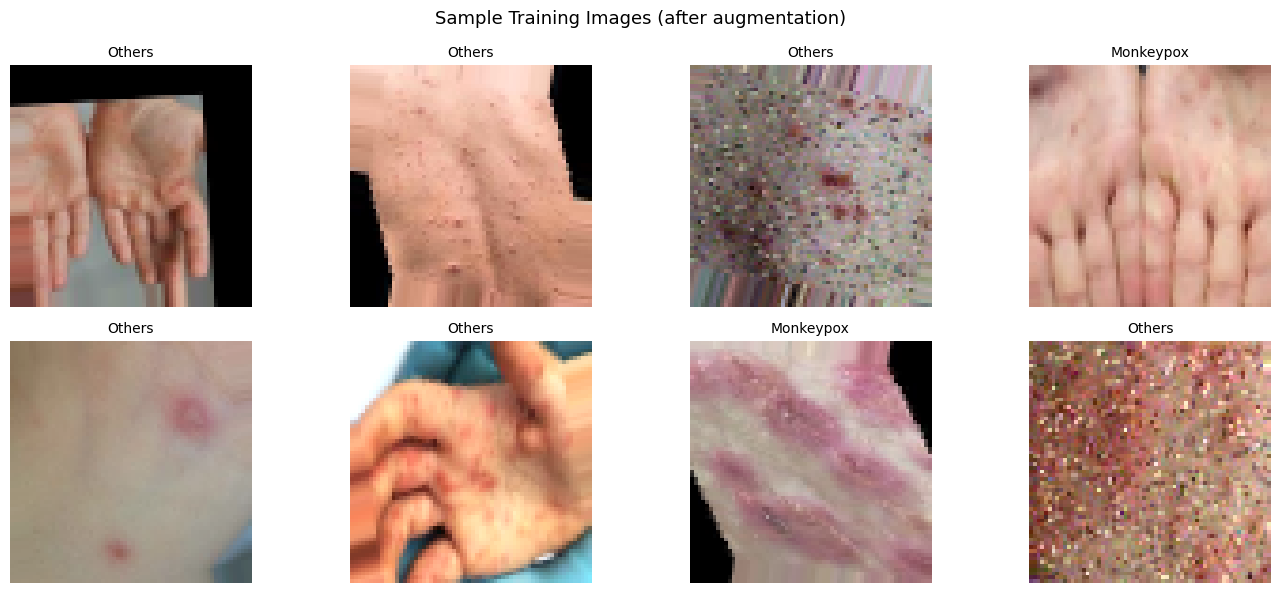

In [7]:
# Visualise a batch of training images to verify data loading
class_names = list(train_generator.class_indices.keys())
imgs, labels = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Sample Training Images (after augmentation)', fontsize=13)

for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(class_names[np.argmax(labels[i])], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Model Architecture

Custom CNN with 4 convolutional blocks, BatchNormalization for training stability, and Dropout layers to prevent overfitting — a known challenge with small medical imaging datasets.

In [8]:
model = Sequential([
    # Block 1 — learn low-level features (edges, textures)
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Block 2 — learn mid-level features (patterns, shapes)
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Block 3 — learn higher-level features
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Block 4 — deepest feature extraction
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Regularisation before dense layers
    Dropout(0.5),
    Flatten(),

    # Fully connected classifier
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(256, activation='relu'),
    Dropout(0.25),

    # Output layer — softmax for binary classification probabilities
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,074 (2.12 MB)

 Trainable params: 554,114 (2.11 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Train the Model

In [16]:
os.makedirs('models', exist_ok=True)

# Save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop early if val accuracy stops improving — prevents wasted compute
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    steps_per_epoch=len(train_generator),
    validation_steps=len(test_generator),
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.6674 - loss: 0.6398
Epoch 1: val_accuracy improved from None to 0.60000, saving model to models/monkeypox_classifier.h5



Epoch 1: finished saving model to models/monkeypox_classifier.h5
134/134 ━━━━━━━━━━━━━━━━━━━━ 35s 261ms/step - accuracy: 0.6573 - loss: 0.6435 - val_accuracy: 0.6000 - val_loss: 0.8687
Epoch 2/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.6715 - loss: 0.6087
Epoch 2: val_accuracy improved from 0.60000 to 0.71111, saving model to models/monkeypox_classifier.h5



Epoch 2: finished saving model to models/monkeypox_classifier.h5
134/134 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - accuracy: 0.6830 - loss: 0.5958 - val_accuracy: 0.7111 - val_loss: 0.5796
Epoch 3/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7148 - loss: 0.5626
Epoch 3: val_accuracy did not improve from 0.71111
134/134 ━━━━━━━━━━━━━━━━━━━━ 41s 251ms/step - accuracy: 0.7264 - loss: 0.5535 - val_accuracy: 0.6444 - val_loss: 0.6442
Epoch 4/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7345 - loss: 0.5431
Epoch 4: val_accuracy did not improve from 0.71111
134/134 ━━━━━━━━━━━━━━━━━━━━ 34s 251ms/step - accuracy: 0.7381 - loss: 0.5286 - val_accuracy: 0.6000 - val_loss: 0.7251
Epoch 5/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.7499 - loss: 0.5072
Epoch 5: val_accuracy did not improve from 0.71111
134/134 ━━━━━━━━━━━━━━━━━━━━ 41s 253ms/step - accuracy: 0.7516 - loss: 0.5093 - val_accuracy: 0.6000 - val_loss: 0.7189
Epoch 6/25
134/134 ━━━━━━━━━━━━━━━━━━


Epoch 6: finished saving model to models/monkeypox_classifier.h5
134/134 ━━━━━━━━━━━━━━━━━━━━ 34s 251ms/step - accuracy: 0.7918 - loss: 0.4620 - val_accuracy: 0.7556 - val_loss: 0.5196
Epoch 7/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8004 - loss: 0.4562
Epoch 7: val_accuracy did not improve from 0.75556
134/134 ━━━━━━━━━━━━━━━━━━━━ 41s 249ms/step - accuracy: 0.7955 - loss: 0.4578 - val_accuracy: 0.6889 - val_loss: 0.6632
Epoch 8/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.8115 - loss: 0.4183
Epoch 8: val_accuracy did not improve from 0.75556
134/134 ━━━━━━━━━━━━━━━━━━━━ 34s 251ms/step - accuracy: 0.8184 - loss: 0.4133 - val_accuracy: 0.6222 - val_loss: 1.2196
Epoch 9/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.8223 - loss: 0.4124
Epoch 9: val_accuracy did not improve from 0.75556
134/134 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.8254 - loss: 0.3967 - val_accuracy: 0.6889 - val_loss: 1.0232
Epoch 10/25
134/134 ━━━━━━━━━━━━━━━━━

## 7. Training Curves

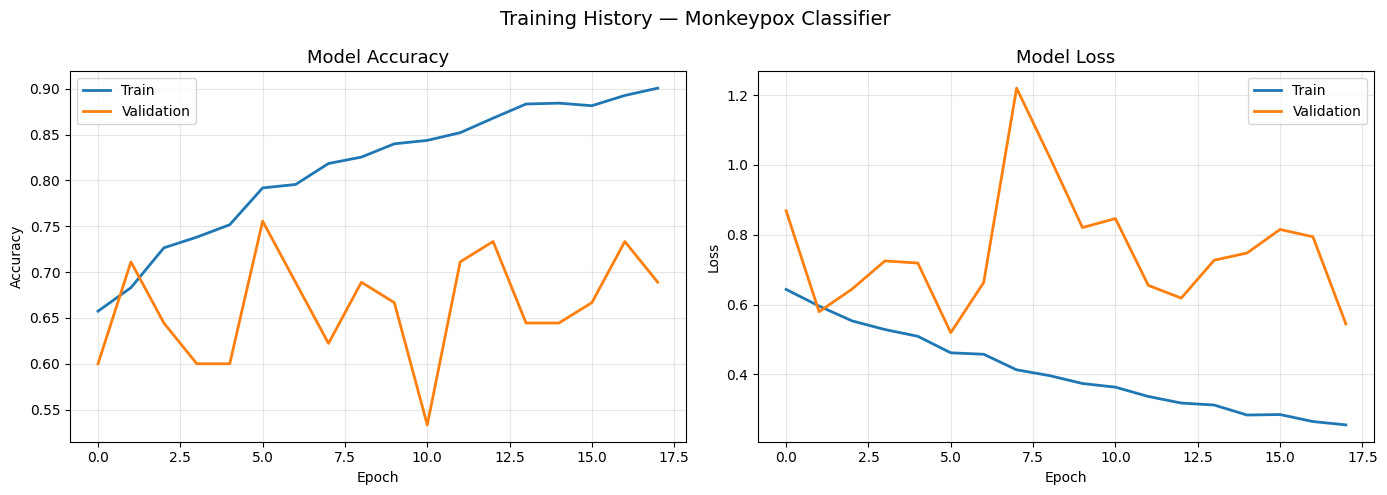


Best Validation Accuracy: 75.56%


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'],     label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — Monkeypox Classifier', fontsize=14)
plt.tight_layout()
plt.savefig('models/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}%")

## 8. Evaluate on Test Set

In [18]:
# Load the best saved model
best_model = load_model(MODEL_SAVE_PATH)

# Evaluate on full test set
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7556 - loss: 0.5196 

Test Accuracy: 75.56%
Test Loss:     0.5196


## 9. Single Image Prediction

Classes: ['Monkeypox', 'Others']


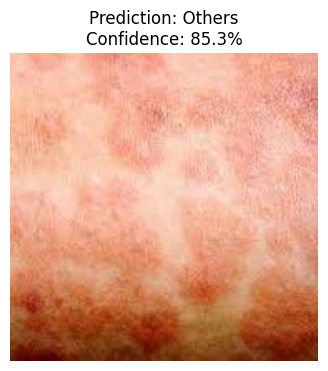

Result: Others (85.3% confidence)


In [20]:
def predict_image(img_path, model, class_names):
    """
    Load a single image and return class prediction with confidence.

    Args:
        img_path: path to the image file
        model: trained Keras model
        class_names: list of class label strings
    """
    # Load and preprocess — must match training pipeline
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0       # normalise to [0,1]
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    # Predict
    preds = model.predict(img_array, verbose=0)
    class_idx = np.argmax(preds[0])
    confidence = preds[0][class_idx]

    # Display
    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(img_path))
    plt.title(f"Prediction: {class_names[class_idx]}\nConfidence: {confidence*100:.1f}%", fontsize=12)
    plt.axis('off')
    plt.show()

    return class_names[class_idx], confidence

# Get class names from training generator
class_names = list(train_generator.class_indices.keys())
print(f"Classes: {class_names}")

# ── Test on a sample image ──────────────────────────────────────────────────
# Replace the path below with any skin lesion image you want to test
SAMPLE_IMAGE = '/content/drive/MyDrive/MONKEYPOX/Test/Others/NM02_01.jpg'

if os.path.exists(SAMPLE_IMAGE):
    label, conf = predict_image(SAMPLE_IMAGE, best_model, class_names)
    print(f"Result: {label} ({conf*100:.1f}% confidence)")
else:
    print(f"Sample image not found at {SAMPLE_IMAGE} — update the path above")